## IMPORT

In [1]:
import os 
import subprocess 
from pathlib import Path
from shutil import copyfile

#always run this cell first


## Utilities

In [2]:
#Utilities for running the code in this repo.

def run_log(cmd, logname=None, cwd=None, show_tail=3, check=True):

    import subprocess
    from pathlib import Path
    from datetime import datetime

    current_folder_path = Path.cwd()

    Path("logs").mkdir(exist_ok=True)

    if logname is None:
        logname = cmd[0]

    logpath = Path("logs") / f"{logname}.log"

    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        cwd=cwd
    )
    
    output = result.stdout.strip()

    # ✅ only create log if there is real output
    if output:
        with open(logpath, "w") as f:
            f.write(output)
        print(f"Saved → {logpath}")

        for line in output.splitlines()[-show_tail:]:
            print("  ", line)
    else:
        pass

    if check and result.returncode != 0:
        raise RuntimeError(f"{cmd[0]} failed. See {logpath}")

    return result






In [5]:
def plot_evt(evt_file, emin=500, emax=7000, bins=250):

    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import LogNorm
    from astropy.io import fits

    # open event file
    with fits.open(evt_file) as f:
        d = f[1].data

    x = d["X"]
    y = d["Y"]
    e = d["ENERGY"]

    # select energy band
    mask = (e >= emin) & (e <= emax)

    x = x[mask]
    y = y[mask]

    # define detector limits (important!)
    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()

    # convert events → image
    H, xedges, yedges = np.histogram2d(
        x, y,
        bins=bins,
        range=[[xmin, xmax], [ymin, ymax]]
    )

    # plot
    plt.figure(figsize=(6,5))

    plt.imshow(
        H.T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        norm=LogNorm()
    )

    plt.colorbar(label="counts")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Brightness Map")

    plt.show()

## Observation folders

In [3]:

current_folder_path = os.getcwd()
data_folder_path = os.path.join(current_folder_path, 'data')

obs_id = []

for farhana in os.listdir(data_folder_path):  #test run to check if the code is working fine. It will print the name of the files in the data folder.
    obs_id.append(farhana.split(' ')[0]) #using space to split as spaces are present in the file names and we only want the obs_id which is the first part of the file name. 

print(obs_id)

['16634', '16626', '16645', '16143', '16464', '16142', '16627', '16635', '16633']


## Repro Chandra observations

In [ ]:
for i in obs_id:
    indir = os.path.join(data_folder_path, i)
    outdir = os.path.join(current_folder_path, 'output', i)
    os.makedirs(outdir, exist_ok=True)
   

    cmd = [  #subprocess is useful as if it encounters an error it will automatically stop the execution of the code and will show the error message in the terminal. Hence useful for loop and debuging.
        "chandra_repro",
        f"indir={indir}",
        f"outdir={outdir}",
        "verbose=1",
        "clobber=yes"
    ]

    run_log(cmd, logname=f"chandra_repro_{i}", cwd=current_folder_path)

## Configure bad pixel file

In [ ]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    bpix = os.path.join(repro_dir, f"acisf{i}_repro_bpix1.fits")

    subprocess.run(["punlearn", "ardlib"], check=True, cwd=str(repro_dir))
    cmd = ["acis_set_ardlib", str(bpix)]
    run_log(cmd, logname=f"acis_set_ardlib_{i}", cwd=repro_dir)


## Flux image create

In [ ]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)

    evt2_path = repro_path / f"acisf{i}_repro_evt2.fits"
    outroot = repro_path / f"{i}"


    cmd =[
    "fluximage",
    str(evt2_path),
    str(outroot),
    "binsize=1",
    "bands=0.5:7:2.3",
    "clobber=yes"
    ]
    
    run_log(cmd, logname=f"fluximage_{i}", cwd=str(repro_path))

## PSF file

In [8]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)


    thresh = repro_path / f"{i}_0.5-7_thresh.img"
    psffile = repro_path / f"{i}_0.5-7.psf"

    subprocess.run(["punlearn", "mkpsfmap"], check=True, cwd=str(repro_path))
    cmd =[
        "mkpsfmap",
        f"infile={thresh}",                 
        f"outfile={psffile}",
        "energy=2.3",
    "ecf=0.9",
    "clobber=yes"
    ]
    run_log(cmd, logname=f"mkpsfmap_{i}", cwd=str(repro_path))  

## Wavdetect

In [7]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)

    thresh = repro_path / f"{i}_0.5-7_thresh.img"
    psffile = repro_path / f"{i}_0.5-7.psf"
    exp = repro_path / f"{i}_0.5-7_thresh.expmap"
    outfile = repro_path / f"{i}_0.5-7_src.fits"
    regfile = repro_path / f"{i}_0.5-7_src.reg"
    

    subprocess.run(["punlearn", "wavdetect"], check=True, cwd=str(repro_path))

    cmd = [

        "wavdetect",
        f"infile={thresh}",
        f"psffile={psffile}",
        f"expfile={exp}",
        f"outfile={outfile}",
        f"scellfile={i}_scell_0.5-7.fits",
        f"imagefile={i}_imgfile_0.5-7.img",
        f"defnbkgfile={i}_defnbkg_0.5-7.fits",
        f"regfile={regfile}",
        "scales=1 2 4 8 16 32",   # single argument containing the scale list
        "maxiter=3",
        "sigthresh=5e-6",
        "ellsigma=5.0",
        "clobber=yes"
    ]
    run_log(cmd, logname=f"wavdetect_{i}", cwd=str(repro_path))


## Remove point sources

In [8]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    nosrc_evt = repro_path / f"{i}_0.5-7_nosrc_evt.fits"
    reg_name = repro_path / f"{i}_0.5-7_src.reg"
    evt2_name = repro_path / f"acisf{i}_repro_evt2.fits"
    

    subprocess.run(["punlearn", "dmcopy"], check=True, cwd=str(repro_path))

    cmd = [
        "dmcopy",
        f"{evt2_name}[exclude sky=region({reg_name})]",
        nosrc_evt,
        "option=all",
        "clobber=yes"
    ]
    run_log(cmd, logname=f"dmcopy_{i}", cwd=str(repro_path))

## PLOT nosrc_evt

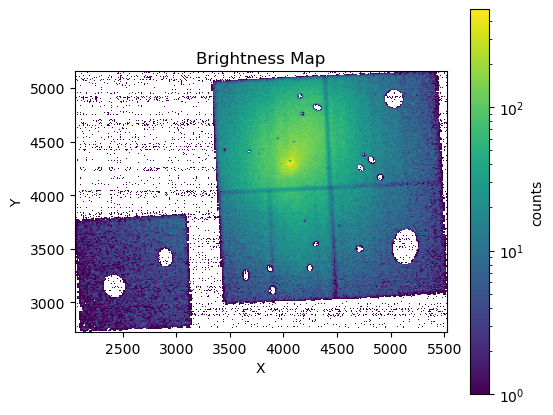

In [7]:
plot_evt("/media/plato/mimic/notebooks/temperaturemap_folder_farhana/output/16142/16142_0.5-7_nosrc_evtfilter.fits")

## Energy filtering

In [10]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    nosrc_evt = repro_path / f"{i}_0.5-7_nosrc_evt.fits"
    nosrc_evtfilter = repro_path / f"{i}_0.5-7_nosrc_evtfilter.fits"

    subprocess.run(["punlearn", "dmcopy"], check=True, cwd=str(repro_path))

    cmd = [
        "dmcopy",
        f"{nosrc_evt}[energy=500:7000]",
        nosrc_evtfilter,
        "option=all",
        "clobber=yes"
    ]

    run_log(cmd, logname=f"dmcopy_{i}", cwd=str(repro_path))

## PLOT no_evtfilter

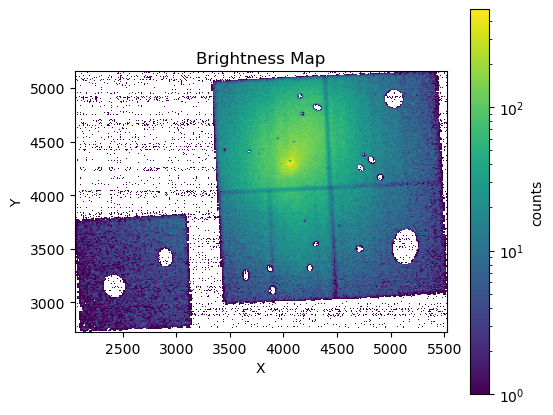

In [11]:
plot_evt("/media/plato/mimic/notebooks/brightnessmap_folder/output/16142/16142_0.5-7_nosrc_evtfilter.fits")

## Create Lightcurve

In [12]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    nosrc_evtfilter = repro_path / f"{i}_0.5-7_nosrc_evtfilter.fits"
    lc_out = repro_path / f"{i}_0.5-7_lc_out"

    
    subprocess.run(["punlearn", "dmextract"], check=True, cwd=str(repro_path))

    cmd = [
        "dmextract",
        f"{nosrc_evtfilter}[bin time=::259.28]",
        lc_out,
        "opt=ltc1",
        "clobber=yes"
    ]

    run_log(cmd, logname=f"dmextract_{i}", cwd=str(repro_path))

## Create GTI

In [ ]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    lc_out = repro_path / f"{i}_0.5-7_lc_out"
    gti = repro_path / f"{i}_0.5-7_gti"

    subprocess.run(["punlearn", "deflare"], check=True, cwd=str(repro_path))

    cmd = [
        "deflare",
        f"infile={lc_out}",
        f"outfile={gti}",
        "method=clean"
    ]
    run_log(cmd, logname=f"deflare_{i}", cwd=str(repro_path))

## Create clean_evt

In [14]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)

    subprocess.run(["punlearn", "dmcopy"], check=True, cwd=str(repro_path))
    evt2 = repro_path / f"acisf{i}_repro_evt2.fits"
    gti = repro_path / f"{i}_0.5-7_gti"
    clean_evt = repro_path / f"{i}_0.5-7_clean_evt.fits"

    cmd = [
        "dmcopy",
        f"{evt2}[@{gti}]",
        f"outfile={clean_evt}",
        "option=all",
        "clobber=yes"
    ]
    run_log(cmd, logname=f"dmcopy_{i}", cwd=str(repro_path))

## PLOT clean_evt

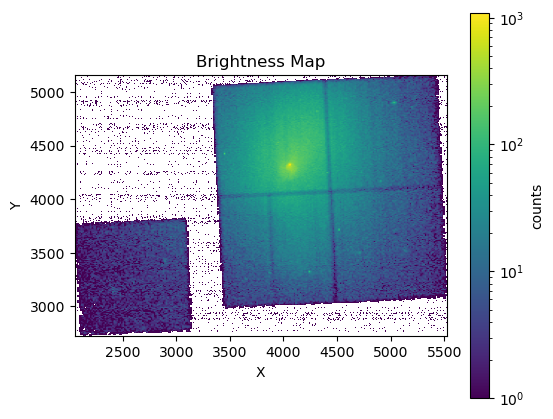

In [15]:
plot_evt("/media/plato/mimic/notebooks/brightnessmap_folder/output/16142/16142_0.5-7_clean_evt.fits")

## Check Active CCDS

In [ ]:
for i in obs_id:
    current_folder_path = os.getcwd()
    data_folder_path = os.path.join(current_folder_path, 'data', i)
    secondary_folder_path = Path("data") / str(i) / "secondary"
    evt1_file = next(secondary_folder_path.glob("*evt1.fits"))

    cmd = [
        "dmkeypar",
        f"infile={evt1_file.name}",
        "keyword=DETNAM",
        "echo=yes"
    ]
    
    run_log(cmd, logname=f"dmkeypar_{i}", cwd=str(secondary_folder_path))

## Store CCD in Analysis

In [17]:
for i in obs_id:
    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    analysis_path = repro_path / "analysis"
    analysis_path.mkdir(exist_ok=True)
    

    for ccd in [0,1,2,3]:
        cmd = [
            "dmcopy",
            f"acisf{i}_repro_evt2.fits[ccd_id={ccd}]",
            f"analysis/acis_ccd{ccd}.fits",
            "clobber=yes"
        ]
        run_log(cmd, logname=f"dmcopy_{i}_ccd{ccd}", cwd=str(repro_path))

## Create  ccd.lis

In [18]:
for i in obs_id:
    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    analysis_path = repro_path / "analysis"
    

    subprocess.run(
    "ls acis_ccd*.fits > acisI.lis",
    shell=True,
    cwd=str(analysis_path)
    )

    cmd = [
        "dmmerge",
        f"infile=@{analysis_path}/acisI.lis[subspace -expno]",
        f"outfile={analysis_path}/acisI.fits",
        "clobber=yes"
    ]
    run_log(cmd, logname=f"dmmerge_{i}", cwd=str(analysis_path)) 

## Background lookup -> Store back.lis

In [ ]:
from pathlib import Path
import subprocess, shutil

for i in obs_id:
    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    analysis_path = repro_path / "analysis"
    
    for ccd in [0,1,2,3]:
        acis_ccd = analysis_path / f"acis_ccd{ccd}.fits"
         
       # run the lookup but keep logs and only print last few lines
        logname = f"{i}_ccd{ccd}_acis_bkgrnd_lookup"
        res = run_log(["acis_bkgrnd_lookup", f"infile={acis_ccd.name}"],
                      logname=logname,
                      cwd=str(analysis_path),
                      show_tail=5,
                      check=False) 
        

        if res.returncode != 0:
            # print(f"[{i}] CCD{ccd}: lookup command failed (rc={res.returncode}) -> see logs/{logname}.log")
            continue
        
        out_lines = [ln.strip() for ln in res.stdout.splitlines() if ln.strip()]
        

        caldb_path = out_lines[-1]                     # the matching CALDB background path
        dst = analysis_path / f"back_ccd{ccd}.fits"    # destination to write immediately

        try:
            shutil.copy(caldb_path, dst)
            #print(f"[{i}] CCD{ccd}: copied {caldb_path} -> {dst.name}")
        except Exception as e:
            print(f"[{i}] CCD{ccd}: copy failed -> {e}")

## Locate pointing files (asol)

In [ ]:
import shutil
from pathlib import Path

#succesfully copied the asol files to the analysis folder. This is important as the reproject step needs the asol files to reproject the background files to match the observation files. If the asol files are not present, the reproject step will fail and we won't be able to proceed with the analysis.
for i in obs_id:

    current_folder_path = os.getcwd()
    data_folder_path = os.path.join(current_folder_path, 'data')
    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    analysis_path = repro_path / "analysis"


    src = repro_path / f"acisf{i}_asol1.lis"
    dst = analysis_path / "pcad_asol1.lis"

    shutil.copy(src, dst)

    print("Copied:", dst)

## Reproject Background

In [22]:
import subprocess
from pathlib import Path

#reprojecting the background files to match the observation files. This is important as the background files need to be in the same coordinate system as the observation files for accurate analysis. If the background files are not reprojected, we might get inaccurate results when we subtract the background from the observation.
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    analysis_path = repro_path / "analysis"


    aspect_file = analysis_path / "pcad_asol1.lis"
    match_evt   = repro_path / f"acisf{i}_repro_evt2.fits"

    for ccd in [0,1,2,3]:

        back = analysis_path / f"back_ccd{ccd}.fits"

        if not back.exists():
            continue

        subprocess.run(["punlearn","reproject_events"], check=True, cwd=str(analysis_path))

        cmd = [
            "reproject_events",
            f"infile={back.name}",
            f"outfile=back_reproj_ccd{ccd}.fits",
            f"aspect=@{aspect_file.name}",
            f"match={match_evt}",
            "random=0",
            "clobber=yes",
            "mode=h"
        ]

        run_log(cmd, logname=f"reproject_events_{i}_ccd{ccd}", cwd=str(analysis_path))
        #print(f"{i} CCD{ccd} done")

## Create merged_back.lis

In [23]:
for i in obs_id:
    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    analysis_path = repro_path / "analysis"


    reproj_files = sorted(analysis_path.glob("back_reproj_ccd*.fits"))

    with open(analysis_path / "backI.lis", "w") as f:
        for file in reproj_files:
            f.write(file.name + "\n")

    with open(analysis_path / "merged_back.lis", "w") as f:
        for file in reproj_files:
            f.write(str(file) + "\n")

    #print(f"{i} → lists created")

## Create Master list

In [24]:
# make the merged background list file

output_path = Path.cwd() / "output"
master_list = output_path / "merged_back_combined.lis"

# Read every line from each obs merged_back.lis and append to one master list (for dmmerge @file)
with open(master_list, "w") as out:
    for i in obs_id:
        lis_path = output_path / str(i) / "analysis" / "merged_back.lis"
        with open(lis_path, encoding="utf-8") as inf:
            for line in inf:
                out.write(line)

print("Wrote", master_list)


Wrote /media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_back_combined.lis


## Dmmerge master list

In [25]:
repro_path = Path.cwd() / "output"
merged_back = repro_path / "merged_background.fits"
master_list = repro_path / "merged_back_combined.lis"


subprocess.run(["punlearn", "dmmerge"], check=True, cwd=str(repro_path))

cmd = [
    "dmmerge",
    f"infile=@{master_list}",
    f"outfile={merged_back}",
    "clobber=yes"
]

run_log(cmd, logname="dmmerge_merged_background", cwd=str(repro_path))

Saved → logs/dmmerge_merged_background.log
   omit - RA_PNT values different more than 0.000300
   omit - ROLL_PNT values different more than 1.000000
   omit - SIM_Z values different more than 0.100000


CompletedProcess(args=['dmmerge', 'infile=@/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_back_combined.lis', 'outfile=/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_background.fits', 'clobber=yes'], returncode=0, stdout='omit - DEC_NOM values different more than 0.000300\nomit - DEC_PNT values different more than 0.000300\nwarning: DETNAM has different value...Merged...\nomit - RA_NOM values different more than 0.000300\nomit - RA_PNT values different more than 0.000300\nomit - ROLL_PNT values different more than 1.000000\nomit - SIM_Z values different more than 0.100000\n')

## Create Clean list path

In [26]:
current_folder_path = Path.cwd()

clean_list_path = current_folder_path / "output" / "clean_evt.list"

with open(clean_list_path, "w") as f:
    for i in obs_id:
        
        clean_evt = ( current_folder_path / "output" / i / f"{i}_0.5-7_clean_evt.fits" )
        f.write(str(clean_evt) + "\n")

print("List written to:", clean_list_path)

List written to: /media/plato/mimic/notebooks/notebook_folder_farhana/output/clean_evt.list


## Run Merge_obs

In [27]:
current_folder_path = Path.cwd()

repro_path = current_folder_path / "output"

merge_dir = repro_path / "merged_obs"
merge_dir.mkdir(exist_ok=True)

clean_list_path = repro_path / "clean_evt.list"

outroot = merge_dir / "merged"

subprocess.run(["punlearn", "merge_obs"], check=True)

cmd = [
    "merge_obs",
    f"@{clean_list_path}",
    str(outroot),
    "bin=1",
    "bands=broad",
    "clobber=yes"
]
run_log(cmd, logname="merge_obs", cwd=str(repro_path))

Saved → logs/merge_obs.log
         the DEC_NOM keyword varies by 0.0110 (limit is 0.0003)
         the ROLL_NOM keyword varies by 5.0 (limit is 1.0)
         the SIM_Z keyword varies by 1.5 (limit is 0.1)


CompletedProcess(args=['merge_obs', '@/media/plato/mimic/notebooks/notebook_folder_farhana/output/clean_evt.list', '/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/merged', 'bin=1', 'bands=broad', 'clobber=yes'], returncode=0, stdout='Running merge_obs\nVersion: 05 November 2021\n\nVerifying 9 observations.\nUsing CSC ACIS broad science energy band.\nCalculating new tangent point.\nNew tangent point: RA=17h 12m 26.147s Dec=-23d 23\' 57.37"\n\nObservations to be reprojected:\n\n  Obsid  Obs Date   Exp    DETNAM     SIM_Z    FP   Sepn   PA  \n                   (ks)                (mm)    (K)   (\')  (deg)\n---------------------------------------------------------------\n1 16142 2014-07-01  32.7 ACIS-01236  -226.748 153.6  < 3"  +100\n2 16626 2014-07-03  30.8 ACIS-01236  -226.748 153.6  < 3"   +78\n3 16627 2014-07-05  34.6 ACIS-01236  -226.748 153.6   0.1  +134\n4 16634 2014-07-11  22.4 ACIS-01236  -226.286 153.9   0.4   -14\n5 16635 2014-07-12  18.9 ACIS-01236  -2

## PLOT merged_evt

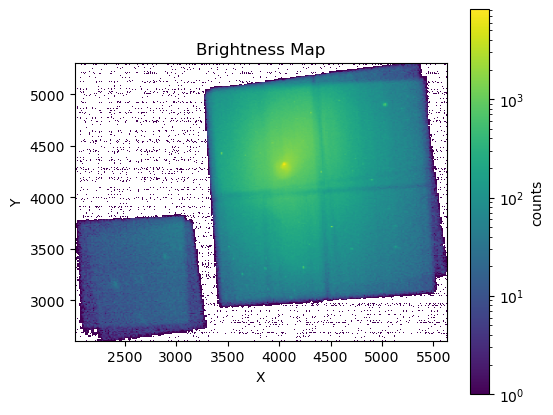

In [28]:
plot_evt("/media/plato/mimic/notebooks/brightnessmap_folder/output/merged_obs/merged_merged_evt.fits")

## Blank SKY section

In [ ]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    evt2 = repro_path / f"acisf{i}_repro_evt2.fits"
    gti = repro_path / f"{i}_0.5-7_gti"
    bkg_evt = repro_path / f"{i}_0.5-7_blank_sky_bkg_evt.fits"


    subprocess.run(["punlearn", "blanksky"], check=True, cwd=str(repro_path))

    subprocess.run([
        "blanksky",
        f'evtfile={evt2}[@{gti}]',
        f"outfile={bkg_evt}",
        "tmpdir=./",
        "clobber=yes"
    ], check=True, cwd=str(repro_path))


In [ ]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    bkg_evt = repro_path / f"{i}_0.5-7_blank_sky_bkg_evt.fits"

    subprocess.run([
        "dmhedit",
        f"infile={bkg_evt}",
        "filelist=none",
        "key=OBS_ID",
        f"value={i}",
        "operation=add"
    ], check=True, cwd=str(repro_path))

In [ ]:
for i in obs_id:

    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    bkg_evt = repro_path / f"{i}_0.5-7_blank_sky_bkg_evt.fits"

    subprocess.run(["punlearn", "blanksky_image"], check=True, cwd=str(repro_path))

    subprocess.run([
        "blanksky_image",
        f"bkgfile={bkg_evt}",
        f"outroot={i}_blank",
        f"imgfile={i}_0.5-7_thresh.img",
        "tmpdir=./",
        "clobber=yes"
    ], check=True, cwd=str(repro_path))

## VFAINT (if needed)

In [ ]:
#Vfaint cleaning the background files. This is important as the VFAINT mode is a special mode of the ACIS instrument that allows for better background cleaning. If the background files are not cleaned, we might get inaccurate results when we subtract the background from the observation.
#Vfaint is for clearing out cosmic rays and other non-X-ray events from the data, which can improve the signal-to-noise ratio in the final analysis. If the observation was taken in VFAINT mode, we need to apply the VFAINT cleaning to the background files to ensure that they are properly cleaned and can be accurately subtracted from the observation.
for i in obs_id:
    repro_dir= os.path.join(current_folder_path, 'output', i)
    repro_path = Path(repro_dir)
    analysis_path = repro_path / "analysis"

    evt1 = next((Path(current_folder_path) / "data" / i / "secondary").glob("*evt1.fits"))

    proc = subprocess.run(
        ["dmkeypar", f"infile={evt1}", "keyword=DATAMODE", "echo=yes"], #reads the evt1 file to check the value of the DATAMODE keyword, which indicates whether the observation was taken in VFAINT mode or not. This is important because if the observation was taken in VFAINT mode, we need to apply the VFAINT cleaning to the background files to ensure that they are properly cleaned and can be accurately subtracted from the observation.
        capture_output=True, text=True, check=True
    )

    if proc.stdout.strip() == "VFAINT":

        for ccd in [0,1,2,3]:
            reproj = analysis_path / f"back_reproj_ccd{ccd}.fits"

            if not reproj.exists():
                continue

            subprocess.run([
                "dmcopy",
                f"{reproj}[status=0]",
                reproj,
                "clobber=yes"
            ], check=True)

        print(f"{i} → VFAINT cleaned")
    else:
        print(f"{i} → Not VFAINT, skipping clean")

## Create NPS_noem in image format

In [33]:
#--------------------------------------
#---- saves_in_image_coordinates -----
#--------------------------------------

import numpy as np
from astropy.io import fits
from scipy.ndimage import gaussian_filter

# ----------------------------
# Input / Output paths
# ----------------------------
flux_file = "/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/merged_broad_thresh.img"
out_file = "./output/nps_noem.reg"

# ----------------------------
# Load FITS image
# ----------------------------
img = np.nan_to_num(fits.getdata(flux_file)).squeeze().astype(float)

# ----------------------------
# Light smoothing (for stability, NOT to shift peak too much)
# ----------------------------
sm = gaussian_filter(img, sigma=2.0, mode="nearest") 

# ----------------------------
# Find global peak (most reliable anchor)
# ----------------------------
igy, igx = np.unravel_index(np.nanargmax(sm), sm.shape)

# ----------------------------
# Local centroid refinement (small window only)
# ----------------------------
win = 30

y0 = max(0, igy - win)
y1 = min(sm.shape[0], igy + win + 1)
x0 = max(0, igx - win)
x1 = min(sm.shape[1], igx + win + 1)

cut = sm[y0:y1, x0:x1]
cut = np.nan_to_num(cut)

yg, xg = np.indices(cut.shape)

weights = cut
wsum = weights.sum()

if wsum > 0:
    cy = y0 + (yg * weights).sum() / wsum
    cx = x0 + (xg * weights).sum() / wsum
else:
    cy, cx = igy, igx

# ----------------------------
# Convert to DS9 IMAGE coords (1-based indexing)
# ----------------------------
cx_ds9 = cx + 1.0
cy_ds9 = cy + 1.0

# ----------------------------
# Radius (kept fixed for stability — replace if needed)
# ----------------------------
radius = 190.0

# ----------------------------
# Write DS9 region file (IMAGE system forced)
# ----------------------------
with open(out_file, "w") as fh:
    fh.write("# Region file format: DS9 version 4.1\n")
    fh.write("image\n")
    fh.write(f"circle({cx_ds9:.4f},{cy_ds9:.4f},{radius:.4f})\n")

print("--------------------------------------------------")
print(f"Saved DS9 region: {out_file}")
print(f"Center (IMAGE coords): ({cx_ds9:.3f}, {cy_ds9:.3f})")
print(f"Radius (pixels): {radius:.3f}")
print("--------------------------------------------------")

--------------------------------------------------
Saved DS9 region: ./output/nps_noem.reg
Center (IMAGE coords): (2051.208, 1737.474)
Radius (pixels): 190.000
--------------------------------------------------


## Run Wavedetect on thresh.img without mask

In [34]:
##run wavdetect
current_folder_path = Path.cwd()
repro_path = current_folder_path / "output"
merge_dir = repro_path / "merged_obs"

# Output region file for point sources
point_src_reg = merge_dir / "broad_src_0.5-7_n.reg"
point_src_fits = merge_dir / "broad_src_0.5-7_n.fits"
broad_thresh_img = merge_dir / "merged_broad_thresh.img"

# Run wavdetect on the masked broad image

subprocess.run(["punlearn", "wavdetect"], check=True, cwd=str(repro_path))

cmd = [
    "wavdetect",
    "psffile=none",
    f"infile={broad_thresh_img}",
    f"outfile={point_src_fits}",
    f"expfile={merge_dir / 'merged_broad_thresh.expmap'}",
    f"scellfile={merge_dir / 'broad_scell_n.fits'}",
    f"imagefile={merge_dir / 'broad_imgfile_n.img'}",
    f"defnbkgfile={merge_dir / 'broad_defnbkg_n.fits'}",
    f"regfile={point_src_reg}",
    "scales=1 2 4 8 16 32",
    "maxiter=3",
    "sigthresh=5e-6",
    "clobber=yes"
]

run_log(cmd, logname="wavdetect_noem", cwd=str(merge_dir))

CompletedProcess(args=['wavdetect', 'psffile=none', 'infile=/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/merged_broad_thresh.img', 'outfile=/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/broad_src_0.5-7_n.fits', 'expfile=/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/merged_broad_thresh.expmap', 'scellfile=/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/broad_scell_n.fits', 'imagefile=/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/broad_imgfile_n.img', 'defnbkgfile=/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/broad_defnbkg_n.fits', 'regfile=/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/broad_src_0.5-7_n.reg', 'scales=1 2 4 8 16 32', 'maxiter=3', 'sigthresh=5e-6', 'clobber=yes'], returncode=0, stdout='')

## Convert Wavdetect files to WCS

In [5]:
#convert ds9 and ciao to wcs
import os
import subprocess
import time
from pathlib import Path

FITS = Path("/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/merged_broad_thresh.img")
REG_A = Path("/media/plato/mimic/notebooks/notebook_folder_farhana/output/nps_noem.reg")
REG_B = Path("/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/broad_src_0.5-7_n.reg")
OUT_A = Path("/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/nps_noem_wcs.reg")
OUT_B = Path("/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/broad_src_0.5-7_n_wcs.reg")

DISPLAY = ":1234"
os.environ["DISPLAY"] = DISPLAY


def xpa(s: str) -> None:
    cmd = ["xpaset", "-p", "ds9", s]
    subprocess.run(cmd, check=True)


def convert_pair_ds9(in_reg: Path, out_reg: Path) -> None:
    out_reg.parent.mkdir(parents=True, exist_ok=True)
    ir, or_ = str(in_reg.resolve()), str(out_reg.resolve())
    xpa("regions delete all")
    xpa(f"regions load {ir}")
    xpa("regions format ds9")
    xpa("regions system wcs")  # or: "regions systems wcs"
    xpa("wcs skyformat sexagesimal")
    xpa(f"regions save {or_}")

def convert_pair_ciao(in_reg: Path, out_reg: Path) -> None:
    out_reg.parent.mkdir(parents=True, exist_ok=True)
    ir, or_ = str(in_reg.resolve()), str(out_reg.resolve())
    xpa("regions delete all")
    xpa(f"regions load {ir}")
    xpa("regions format ciao")
    xpa("regions system wcs")  # or: "regions systems wcs"
    xpa("wcs skyformat sexagesimal")
    xpa(f"regions save {or_}")


cmd = ["Xvfb", DISPLAY, "-screen", "0", "1024x768x24"]
xvfb = subprocess.Popen(cmd)
time.sleep(1)

ds9 = None
try:
    cmd = ["ds9", str(FITS.resolve())]
    ds9 = subprocess.Popen(cmd)
    time.sleep(4)

    convert_pair_ds9(REG_A, OUT_A)
    convert_pair_ciao(REG_B, OUT_B)

    cmd = ["xpaset", "-p", "ds9", "exit"]
    subprocess.run(cmd, check=False)
    if ds9 is not None:
        ds9.wait(timeout=60)
finally:
    if ds9 is not None and ds9.poll() is None:
        ds9.terminate()
    xvfb.terminate()
    try:
        xvfb.wait(timeout=5)
    except subprocess.TimeoutExpired:
        xvfb.kill()

## Filters nps and src regions

In [6]:
from pathlib import Path
from regions import Regions, CircleSkyRegion, EllipseSkyRegion

# --- files ---
CORE_REG = Path("/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/nps_noem_wcs.reg")
SRC_REG = Path("/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/broad_src_0.5-7_n_wcs.reg")
CLEAN_REG = Path("/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/broad_src_clean.reg")
OUT_REG = Path("/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/broad_src_filtered_wcs.reg")


# =========================================================
# 1. CLEAN SOURCE FILE (fix icrs + remove bad ellipses)
# =========================================================
with open(SRC_REG) as f_in, open(CLEAN_REG, "w") as f_out:
    lines = f_in.readlines()

    # ensure header
    has_icrs = any("icrs" in l.lower() for l in lines[:5])
    if not has_icrs:
        f_out.write("# Region file format: DS9 version 4.1\n")
        f_out.write("icrs\n")

    for line in lines:
        if "ellipse" in line:
            parts = line.strip().split(",")

            try:
                w = parts[2]
                h = parts[3]

                if "0.00000" in w or "0.00000" in h:
                    continue  # skip bad regions
            except Exception:
                continue  # skip malformed lines

        f_out.write(line)

print(f"Cleaned file → {CLEAN_REG}")


# =========================================================
# 2. LOAD REGIONS
# =========================================================
src_regs = Regions.read(CLEAN_REG, format="ds9")
core_reg = Regions.read(CORE_REG, format="ds9")[0]


# =========================================================
# 3. OVERLAP FUNCTION
# =========================================================
def overlaps(core: CircleSkyRegion, r) -> bool:
    # try exact method first
    if hasattr(r, "intersects"):
        try:
            return r.intersects(core)
        except Exception:
            pass

    # fallback: center distance
    d = core.center.separation(r.center)

    if isinstance(r, CircleSkyRegion):
        return d <= (core.radius + r.radius)

    if isinstance(r, EllipseSkyRegion):
        reach = max(r.width, r.height) / 2  # conservative
        return d <= (core.radius + reach)

    return False


# =========================================================
# 4. FILTER
# =========================================================
filtered = [r for r in src_regs if not overlaps(core_reg, r)]


# =========================================================
# 5. SAVE
# =========================================================
Regions(filtered).write(OUT_REG, format="ds9", overwrite=True)

print(f"Kept {len(filtered)} / {len(src_regs)} regions → {OUT_REG}")

Cleaned file → /media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/broad_src_clean.reg
Kept 154 / 164 regions → /media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/broad_src_filtered_wcs.reg


## Verify if counts img is in WCS

In [7]:
from astropy.io import fits
from astropy.wcs import WCS

file = "/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/merged_broad_thresh.img"

with fits.open(file) as hdul:
    header = hdul[0].header

wcs = WCS(header)

print(wcs)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 258.10894680449 -23.399268481129
CRPIX : 2095.5 1516.5
PC1_1 PC1_2  : 1.0 0.0
PC2_1 PC2_2  : 0.0 1.0
CDELT : -0.00013666666666667 0.00013666666666667
NAXIS : 3647  2747


Set MJD-END to 56878.484421 from DATE-END'. [astropy.wcs.wcs]


## Convert counts img to fits

In [ ]:
# Convert CIAO counts image -> standard FITS (WCS preserved)

current_folder_path = Path.cwd()
repro_path = current_folder_path / "output"
merge_dir = repro_path / "merged_obs"

from astropy.io import fits

input_file = "/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/merged_broad_thresh.img"
output_file = merge_dir / "merged_broad_counts.fits"

with fits.open(input_file) as hdul:
    data = hdul[0].data
    header = hdul[0].header

fits.writeto(output_file, data, header, overwrite=True)

print("Done!")
print("Saved:", output_file)

Done!
Saved: /media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/merged_broad_counts.fits


## Filtered Counts fit

In [ ]:
current_folder_path = Path.cwd()
repro_path = current_folder_path / "output"
merge_dir = repro_path / "merged_obs"

count_final = merge_dir / "merged_broad_counts.fits" #Wcs
point_src_reg = "broad_src_filtered_physical.reg" #ciao only understands physical
count_no_ptsrc = merge_dir / "merged_broad_counts_final_nosrc.fits"

subprocess.run(["punlearn", "dmcopy"], check=True, cwd=str(merge_dir))

cmd = [
    "dmcopy",
    f"{count_final}[exclude sky=region({point_src_reg})]", #ciao parses as one whole virtual expression, so avoid quotations
    count_no_ptsrc,
    "clobber=yes"
]

run_log(cmd, logname="dmcopy_remove_ptsrc", cwd=str(merge_dir))

CompletedProcess(args=['dmcopy', '/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/merged_broad_counts.fits[exclude sky=region(broad_src_filtered_physical.reg)]', PosixPath('/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/merged_broad_counts_final_nosrc.fits'), 'clobber=yes'], returncode=0, stdout='')

## Crop to square region (physical)

In [21]:
current_folder_path = Path.cwd()
repro_path = current_folder_path / "output"
merge_dir = repro_path / "merged_obs"

count_no_ptsrc = merge_dir / "merged_broad_counts_final_nosrc.fits"
square_file = merge_dir / "square_physical.reg"
count_final_cropped = merge_dir / "merged_broad_counts_final_cropped.fits"

subprocess.run(["punlearn", "dmcopy"], check=True, cwd=str(merge_dir))

cmd = [
    "dmcopy",
    f"{count_no_ptsrc}[sky=region({square_file})]", #ciao parses as one whole virtual expression, so avoid quotations
    count_final_cropped,
    "clobber=yes"
]

run_log(cmd, logname="dmcopy_final_crop", cwd=str(merge_dir))

CompletedProcess(args=['dmcopy', '/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/merged_broad_counts_final_nosrc.fits[sky=region(/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/square_physical.reg)]', PosixPath('/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/merged_broad_counts_final_cropped.fits'), 'clobber=yes'], returncode=0, stdout='')

## Determine smoothsn and sn 

In [2]:
import numpy as np
from astropy.io import fits

def suggest_contbin_params(fits_file):
    # Load counts image
    with fits.open(fits_file) as hdul:
        data = hdul[0].data.astype(float)

    # Remove NaNs / zeros
    data = data[np.isfinite(data)]
    data = data[data > 0]

    total_counts = np.sum(data)
    mean_counts = np.mean(data)

    print(f"Total counts: {total_counts:.2e}")
    print(f"Mean counts per pixel: {mean_counts:.2f}")

    # Heuristic suggestions
    if total_counts < 1e4:
        sn = 20
        smoothsn = 3
    elif total_counts < 1e5:
        sn = 30
        smoothsn = 4
    elif total_counts < 5e5:
        sn = 50
        smoothsn = 5
    else:
        sn = 70
        smoothsn = 5

    print("\nSuggested parameters:")
    print(f"sn        ≈ {sn}")
    print(f"smoothsn  ≈ {smoothsn}")

    print("\nTip:")
    print("- Increase sn for better spectra")
    print("- Decrease sn for more spatial detail")

    return sn, smoothsn

In [3]:
sn, smoothsn = suggest_contbin_params("/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/merged_broad_counts_final_cropped.fits")

Total counts: 5.49e+06
Mean counts per pixel: 2.76

Suggested parameters:
sn        ≈ 70
smoothsn  ≈ 5

Tip:
- Increase sn for better spectra
- Decrease sn for more spatial detail


## Run Contbin

In [10]:
from pathlib import Path
import subprocess

current_folder_path = Path.cwd()

repro_path = current_folder_path / "output"

merge_dir = repro_path / "merged_obs"

# Create dedicated contbin output directory
contbin_dir = merge_dir / "contbin_outputs"
contbin_dir.mkdir(exist_ok=True)

# Input file
counts_file = merge_dir / "merged_broad_counts_final_cropped.fits"

# Output prefix (all contbin products go here)
outroot = contbin_dir / "contbin_sn70"

cmd = [
    "contbin",
    "--sn=70",
    "--smoothsn=5",
    "--constrainfill",
    "--constrainval=3",
    str(counts_file)
]

run_log(cmd, logname="contbin_sn70", cwd=str(contbin_dir))

Saved → logs/contbin_sn70.log
   Writing image (1809x1685)
   Closing contbin_mask.fits
   Closing /media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/merged_broad_counts_final_cropped.fits


CompletedProcess(args=['contbin', '--sn=70', '--smoothsn=5', '--constrainfill', '--constrainval=3', '/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/merged_broad_counts_final_cropped.fits'], returncode=0, stdout='(i) Loading image /media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/merged_broad_counts_final_cropped.fits\nOpening /media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/merged_broad_counts_final_cropped.fits (RO)\nReading image (1809x1685)\n(i) Using blank foreground exposure (exp=229048)\n(i) Using blank background exposure (exp=1)\n(i) Smoothing data (S/N = 5)\n\n    0.00%\n  0.0593%\n   0.119%\n   0.178%\n   0.237%\n   0.297%\n   0.356%\n   0.415%\n   0.475%\n   0.534%\n   0.593%\n   0.653%\n   0.712%\n   0.772%\n   0.831%\n   0.890%\n   0.950%\n    1.01%\n    1.07%\n    1.13%\n    1.19%\n    1.25%\n    1.31%\n    1.36%\n    1.42%\n    1.48%\n    1.54%\n    1.60%\n    1.66%\n    1.72%\n    1.78%\n    1.84%\n    1

## Determine Min_x, Min_y

In [11]:
from astropy.io import fits
current_folder_path = Path.cwd()

repro_path = current_folder_path / "output"

merge_dir = repro_path / "merged_obs"

contbin_dir = merge_dir / "contbin_outputs"

fname = contbin_dir/ "contbin_binmap.fits"

with fits.open(fname) as hdul:
    hdr = hdul[0].header

# CIAO images normally store origin in these keywords
min_x = hdr.get("CRPIX1", 1)
min_y = hdr.get("CRPIX2", 1)

print("min_x =", min_x)
print("min_y =", min_y)

min_x = 637.5
min_y = 855.5


## Make region files

In [12]:

from pathlib import Path

current_folder_path = Path.cwd()

repro_path = current_folder_path / "output"
merge_dir = repro_path / "merged_obs"

contbin_dir = merge_dir / "contbin_outputs"

min_x = 637.5
min_y = 855.5

# output directory
outreg_dir = merge_dir / "outreg"
outreg_dir.mkdir(exist_ok=True)

input_file = contbin_dir / "contbin_binmap.fits"

cmd = [
    "make_region_files",
    f"--minx={min_x}",
    f"--miny={min_y}",
    "--bin=1",
    f"--outdir={str(outreg_dir)}",
    str(input_file)
]

run_log(cmd, logname="make_regionfiles", cwd=str(merge_dir))


Saved → logs/make_regionfiles.log
   Bin 786 (/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/outreg/xaf_786.reg)
   Bin 787 (/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/outreg/xaf_787.reg)
   Bin 788 (/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/outreg/xaf_788.reg)


CompletedProcess(args=['make_region_files', '--minx=637.5', '--miny=855.5', '--bin=1', '--outdir=/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/outreg', '/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/contbin_outputs/contbin_binmap.fits'], returncode=0, stdout='Input binmap: /media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/contbin_outputs/contbin_binmap.fits\nOutput directory: /media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/outreg\nMinimum x: 637.5\nMinimum y: 855.5\nBinning factor: 1\nOpening /media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/contbin_outputs/contbin_binmap.fits (RO)\nReading image (1809x1685)\nClosing /media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/contbin_outputs/contbin_binmap.fits\nBin 0 (/media/plato/mimic/notebooks/notebook_folder_farhana/output/merged_obs/outreg/xaf_0.reg)\nBin 1 (/media/plato/mimic/notebooks/notebook_folder_far

## Convert region to WCS

In [ ]:
import os
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
import subprocess



# ----------------------------
# Robust contbin region parser (rotbox only)
# ----------------------------
def parse_region_line(line):
    if "rotbox" not in line:
        return None

    vals = line.split("rotbox(")[1].split(")")[0].split(",")
    vals = [float(v) for v in vals]

    # x, y in pixels; dx, dy in pixels; angle in degrees
    x, y, dx, dy, angle = vals
    return x, y, dx, dy, angle


# ----------------------------
# Paths
# ----------------------------

current = Path.cwd()
log_dir = current / "logs"
log_file = log_dir/ "pipeline_debug.log"
log_file.parent.mkdir(exist_ok=True)

repro_path = current / "output"
merge_dir = repro_path / "merged_obs"

input_reg_dir = merge_dir / "outreg"
output_dir = merge_dir / "outreg_fk5"
output_dir.mkdir(exist_ok=True)

wcs_image = merge_dir / "merged_broad_counts_final_cropped.fits"

# ----------------------------
# log func
# ----------------------------
def log(msg):
    with open(log_file, "a") as f:
        f.write(str(msg) + "\n")


# ----------------------------
# Load WCS
# ----------------------------
with fits.open(wcs_image) as hdul:
    w = WCS(hdul[0].header)


# pixel scale (arcsec/pixel)
pixel_scale = abs(wcs_image and w.pixel_scale_matrix[1,1]) if hasattr(w, "pixel_scale_matrix") else 1.0
pixel_scale = 1.0  # fallback safe default; replace if known


# ----------------------------
# Convert contbin rotbox → FK5 box
# ----------------------------
for reg in sorted(input_reg_dir.glob("*.reg")):

    out_file = output_dir / f"{reg.stem}_fk5.reg"

    text = reg.read_text().splitlines()

    out_lines = [
        "# Region file format: DS9 version 4.1",
        "fk5"
    ]

    for line in text:
        parsed = parse_region_line(line)
        if parsed is None:
            continue

        x, y, dx, dy, angle = parsed

        # ----------------------------
        # pixel → sky center
        # ----------------------------
        ra_deg, dec_deg = w.wcs_pix2world(x, y, 0)

        c = SkyCoord(ra_deg*u.deg, dec_deg*u.deg, frame="icrs")

        # ----------------------------
        # sexagesimal (for readability only)
        # ----------------------------
        ra_str = c.ra.to_string(unit=u.hour, sep=':')
        dec_str = c.dec.to_string(sep=':')

        # ----------------------------
        # convert size: pixels → arcsec
        # ----------------------------
        dx_arcsec = dx * pixel_scale
        dy_arcsec = dy * pixel_scale

        # ----------------------------
        # DS9 FK5 box (CONSISTENT FORMAT)
        # ----------------------------
        out_lines.append(
            f"box({ra_str},{dec_str},{dx_arcsec}\",{dy_arcsec}\",{angle})"
        )

    out_file.write_text("\n".join(out_lines) + "\n")

    # ----------------------------
    # logging (CIAO + Python unified)
    # ----------------------------
    log(f"{reg.name}: wrote {out_file} with {converted} regions")

    print("wrote", out_file)


log("Region conversion complete")

## Spectra

In [ ]:
import subprocess

evt2_path = "/media/plato/mimic/notebooks/temperaturemap_folder_farhana/output/16645/acisf16645_repro_evt2.fits"
fovfile = "/media/plato/mimic/notebooks/temperaturemap_folder_farhana/output/16645/acisf16645_repro_fov1.fits"
reg = "/media/plato/mimic/notebooks/temperaturemap_folder_farhana/output/merged_obs/outreg_fk5/xaf_749_fk5.reg"

infile = f"{evt2_path}[sky=region({fovfile})][sky=region({reg})]"

subprocess.run(["dmstat", infile], check=True)

In [3]:
sum(1 for line in open("/media/plato/mimic/notebooks/temperaturemap_folder_farhana/output/merged_obs/outreg_fk5/xaf_749_fk5.reg") if "box(" in line)

80

In [ ]:
from pathlib import Path
import os
import subprocess 
from shutil import copyfile


#--------------------------------------------------
#Padded string function
#--------------------------------------------------

def pad_string(string):

    length = len(string)

    if length < 5:
        padded_str = '0' * (5 - length) + string
    else:
        padded_str = string

    return padded_str

# --------------------------------------------------
# Paths
# --------------------------------------------------
current_folder_path = Path.cwd()

repro_path = current_folder_path / "output"
merge_dir = repro_path / "merged_obs"

spec_dir = merge_dir / "spectra"
spec_dir.mkdir(exist_ok=True)

reg_dir = merge_dir / "outreg_fk5"


# --------------------------------------------------
# Spectrum extraction
# --------------------------------------------------
for i in obs_id:

    repro_dir = repro_path / i

    padded_obsid = pad_string(i)

    evt2_path = repro_dir / f"acisf{padded_obsid}_repro_evt2.fits"

    for reg in reg_dir.glob("*.reg"):

        # --------------------------------------------------
        # Check if this OBSID contains photons in this region
        # --------------------------------------------------
        check_cmd = [
            "dmstat",
            f"{evt2_path}[sky=region({reg})][energy=500:2000]"
        ]

        result = run_log(
            check_cmd,
            logname=f"check_{i}_{reg.stem}",
            cwd=str(merge_dir),
            check=False
        )

        # skip empty regions
        if "no rows found" in result.stdout.lower():
            continue

        # --------------------------------------------------
        # Run specextract
        # --------------------------------------------------
        outroot = spec_dir / f"{i}_{reg.stem}"

        cmd = [
            "specextract",

            f"infile={evt2_path}[sky=region({reg})]",

            "bkgfile=NONE",

            f"outroot={outroot}",

            "weight=yes",

            "clobber=yes"
        ]

        run_log(
            cmd,
            logname=f"specextract_{i}_{reg.stem}",
            cwd=str(merge_dir)
        )